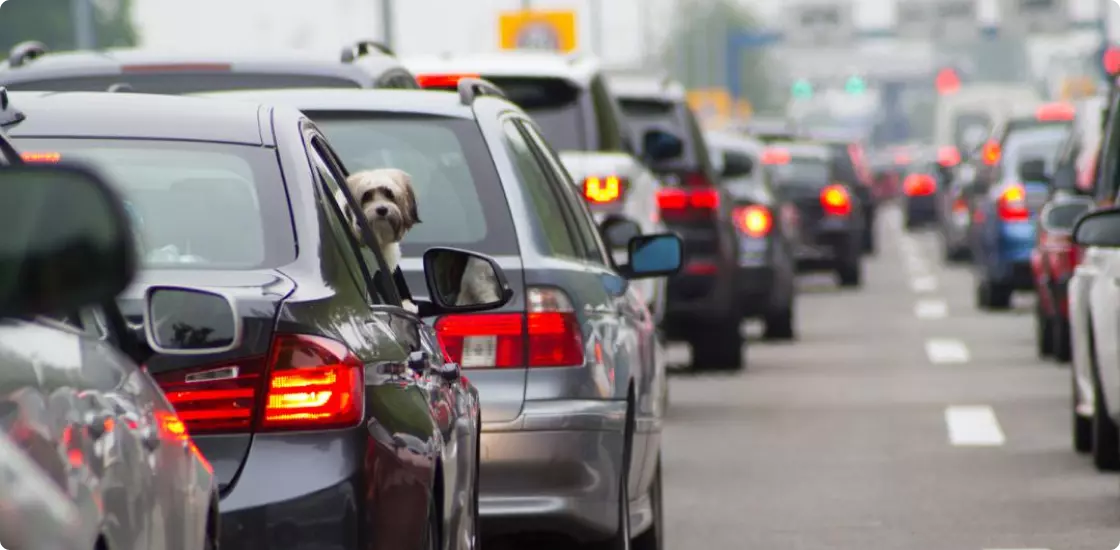

# **US Traffic Accident Analysis**

## Identifying Actionable Opportunities to Improve Road Safety

**Author:** Bennett Trott

**Stakeholder:** United States Department of Transportation (DOT)

**Dataset:** US Accidents (2016-2023)

**Data source:** Kaggle

## Overview

This project analyzes US traffic-accident records from 2016 through 2023 to help the United States Department of Transportation identify actionable opportunities for improving road safety. The analysis examines accident frequency and severity across temporal, environmental, geographic, and roadway conditions.

The project includes data cleaning, exploratory data analysis, statistical testing, and an interactive Tableau dashboard. Its final purpose is to provide the DOT with at least three evidence-based recommendations for prioritizing safety resources, infrastructure improvements, and targeted interventions.

### Bottom Line Up Front (BLUF)

The completed analysis will highlight the three findings most relevant to DOT decision-making:

1. **[Finding 1]:** To be completed after the analysis.
2. **[Finding 2]:** To be completed after the analysis.
3. **[Finding 3]:** To be completed after the analysis.

These findings will be connected to specific recommendations, implementation considerations, and measurable indicators of success.

> **Note:** The BLUF findings are intentionally left as placeholders during the initial project setup. This section will be finalized after the exploratory and statistical analyses are complete. Come back and fill this out once investigative analysis is conducted. Remove this temporary note once the final findings are inserted.

## Business Understanding

### Business Problem

Traffic accidents create substantial public-safety and economic consequences across the United States. In addition to injuries and fatalities, accidents contribute to medical expenses, property damage, traffic congestion, emergency-response costs, and lost productivity.

The United States Department of Transportation (DOT) must determine how limited funding and safety resources can be allocated effectively. Data-driven analysis can help the DOT identify when, where, and under what conditions serious accidents are most frequently recorded. These findings can support infrastructure planning, targeted enforcement, public-warning systems, and emergency-response preparation.

### Relevance of the Data

The US Accidents dataset contains traffic-accident records from across the United States between 2016 and 2023. It includes information about:

- Accident severity
- Date and time
- Geographic location
- Weather and visibility
- Precipitation and other environmental measurements
- Daylight and twilight conditions
- Roadway features such as junctions, crossings, traffic signals, and stop signs

These variables allow accident frequency and severity to be investigated across temporal, environmental, geographic, and roadway conditions. This makes the dataset directly relevant to the DOT's goal of identifying conditions and locations that may benefit from targeted safety interventions.

The dataset contains reported accident records rather than a complete measure of all accidents or total driving exposure. Therefore, raw accident counts will not automatically be interpreted as accident risk. Population, traffic volume, vehicle miles traveled, and differences in reporting coverage may also influence recorded accident totals.

### Project Objective

The objective of this project is to identify meaningful patterns associated with recorded accident frequency and severity and translate those patterns into at least three actionable recommendations for the DOT.

The analysis is intended to help the DOT:

1. Identify conditions associated with a higher proportion of severe accidents.
2. Prioritize time periods, locations, and roadway environments for safety interventions.
3. Support infrastructure, enforcement, public-warning, and emergency-response decisions.
4. Establish measurable indicators for evaluating future safety initiatives.
5. Communicate important accident patterns to non-technical stakeholders through an interactive Tableau dashboard.

### Analytical Questions

The project will be guided by the following questions:

#### 1. Temporal and lighting conditions

How do recorded accident frequency and severity vary by hour of day, day of week, month, season, and lighting condition?

This question can help determine whether particular time periods or low-light conditions warrant additional lighting, enforcement, public warnings, or emergency-response resources.

#### 2. Environmental conditions

How are weather, visibility, precipitation, and other environmental conditions associated with accident severity?

This question can help the DOT evaluate weather-responsive interventions such as reduced-speed warnings, variable-message signs, road treatment, and targeted safety communications.

#### 3. Roadway features

Are roadway features such as junctions, crossings, traffic signals, stop signs, and railway crossings associated with differences in accident severity?

This question can help identify roadway environments that may benefit from engineering reviews, improved signage, lighting, signal modifications, or other infrastructure improvements.

#### 4. Geographic patterns

Which states, cities, or counties contain the largest concentrations of recorded accidents, and which have the highest proportions of severe recorded accidents?

This question can provide geographic context for prioritizing further investigation and resource allocation. Raw accident totals will be interpreted cautiously because the dataset does not directly measure traffic exposure.

### Stakeholders and Intended Audience

The primary stakeholder is the United States Department of Transportation, particularly officials responsible for road-safety strategy, transportation policy, and funding allocation.

Additional stakeholders include:

- State departments of transportation
- Transportation planners and traffic-safety engineers
- State and local governments
- Law-enforcement agencies
- Emergency medical and incident-response services
- Public-works departments
- Policymakers responsible for transportation funding
- Members of the public seeking understandable road-safety information

The notebook and Tableau dashboard will be designed for both technical and non-technical audiences. Findings will be presented using clear visualizations, plain-language interpretations, and specific recommendations supported by measurable evidence.

### Expected Business Benefits

This analysis could help transportation officials:

- Direct limited safety funding toward relevant conditions and locations.
- Schedule enforcement and emergency-response resources during high-priority periods.
- Identify roadway environments that warrant engineering review.
- Develop targeted weather and low-visibility safety interventions.
- Establish evidence-based support for infrastructure and policy decisions.
- Communicate safety priorities clearly to policymakers, local governments, and the public.

The project will ultimately provide three data-supported recommendations. Each recommendation will include a proposed action, its supporting evidence, potential implementation challenges, and metrics the DOT could use to evaluate its effectiveness.

## Data Understanding (16 Steps: 1A - 20A)

The purpose of this section is to load the US Accidents dataset, inspect its structure, document the meaning and relevance of each variable, and identify data-quality issues that may affect the analysis.

Because the dataset is large, the initial inspection will focus on understanding the columns, data types, missing values, duplicate records, severity distribution, time coverage, geographic coverage, and potential outliers. These findings will guide the data-cleaning and feature-engineering decisions in the next section.

#### 1A Import libraries and set display options

In [ ]:
# Import core data analysis libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import path library for file handling
from pathlib import Path

# Set display options for easier notebook review
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

#### 2A Define file path and confirm dataset exists

In [ ]:
# Define dataset path
data_path = Path("Data/US_Accidents_March23.csv")

# Confirm the file exists before loading
print("Dataset found:", data_path.exists())

# Show file size in GB
if data_path.exists():
    file_size_gb = data_path.stat().st_size / 1_000_000_000
    print(f"File size: {file_size_gb:.2f} GB")

Dataset found: True
File size: 3.06 GB


#### 3A Preview the dataset without loading everything

In [4]:
# Load only the first few rows to inspect structure
sample_df = pd.read_csv(data_path, nrows=5)

# Display sample rows
sample_df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.90,NaN,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.90,NaN,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.00,33.30,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.10,31.00,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.00,33.30,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


#### 4A Inspect column names

In [5]:
# Display all column names
columns = sample_df.columns.tolist()

print(f"Number of columns: {len(columns)}")
columns

Number of columns: 46


['ID',
 'Source',
 'Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

#### 5A Load a larger sample for initial data understanding

Since the dataset is large, we’ll inspect a representative sample first. This helps us understand data types, missingness, and value ranges quickly

In [6]:
# Load a manageable sample for initial inspection
sample_size = 100_000

df_sample = pd.read_csv(data_path, nrows=sample_size)

print(f"Sample shape: {df_sample.shape}")
df_sample.head()

Sample shape: (100000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.90,NaN,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.90,NaN,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.00,33.30,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.10,31.00,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.00,33.30,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


This means your sample successfully loaded 100,000 rows and all 46 columns from the dataset.

One important note: because this code uses: 

*pd.read_csv(data_path, nrows=sample_size)*

It loads the first 100,000 rows, not a random sample. Since the dataset appears to be ordered by time, this sample starts with early 2016 records and may overrepresent certain early states, like Ohio. That is completely fine for initial structure inspection, but later, for broader EDA, we may want to load selected columns from the full dataset or create a more representative sampled dataset.

#### 6A Basic structure

In [7]:
# Review data types and non-null counts
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 100000 non-null  object 
 12  City                   99999 non-null   object 
 13  County                 100000 non-null  object 
 14  State                  100000 non-nul

#### 7A Basic descriptive statistics

In [8]:
# Descriptive statistics for numeric columns
df_sample.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,"100,000.00","100,000.00","100,000.00",0.00,0.00,"100,000.00","98,409.00","4,322.00","98,144.00","98,708.00","98,154.00","76,180.00","7,368.00"
mean,2.45,35.63,-119.32,NaN,NaN,0.01,66.64,48.85,59.79,29.96,9.34,8.04,0.03
std,0.50,2.10,3.66,NaN,NaN,0.26,12.70,19.90,23.18,0.28,1.89,4.30,0.05
min,1.00,32.54,-123.81,NaN,NaN,0.00,3.20,-8.40,4.00,2.98,0.10,0.00,0.00
25%,2.00,33.96,-121.83,NaN,NaN,0.00,57.90,37.10,43.00,29.89,10.00,4.60,0.00
50%,2.00,34.17,-118.38,NaN,NaN,0.00,66.00,42.50,62.00,29.97,10.00,6.90,0.00
75%,3.00,37.78,-117.92,NaN,NaN,0.01,75.00,63.00,78.00,30.06,10.00,10.40,0.03
max,4.00,41.43,-81.55,NaN,NaN,51.13,114.10,107.00,100.00,33.04,80.00,241.70,0.55


In [9]:
# Descriptive statistics for categorical/object columns
df_sample.describe(include="object")

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,100000,100000,100000,100000,100000,100000,99999,100000,100000,99993,100000,99993,99993,98946,98936,98396,99999,99999,99999,99999
unique,100000,2,98896,96724,71519,9119,785,71,3,12001,1,2,121,37246,24,43,2,2,2,2
top,A-99967,Source2,2016-04-10 08:59:26,2016-10-14 19:50:00,Accident on I-80 Westbound at Exits 8A 8B I-880.,I-5 N,Los Angeles,Los Angeles,CA,91706,US,US/Pacific,KCQT,2016-11-03 10:53:00,Calm,Clear,Day,Day,Day,Day
freq,1,99950,35,24,55,2921,9792,33466,99272,712,100000,99265,7372,37,21920,57255,62510,66178,70266,74325


#### 8A Create an initial data dictionary

This table directly addresses the requirement to document each variable’s meaning and relevance.

In [10]:
data_dictionary = pd.DataFrame({
    "Column": [
        "ID", "Source", "Severity", "Start_Time", "End_Time", "Start_Lat", "Start_Lng",
        "End_Lat", "End_Lng", "Distance(mi)", "Description", "Street", "City", "County",
        "State", "Zipcode", "Country", "Timezone", "Airport_Code", "Weather_Timestamp",
        "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
        "Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)", "Weather_Condition",
        "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
        "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal",
        "Turning_Loop", "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight",
        "Astronomical_Twilight"
    ],
    "Meaning": [
        "Unique accident record identifier.",
        "Source from which the accident record was collected.",
        "Accident severity level in the dataset.",
        "Timestamp when the accident began.",
        "Timestamp when the accident ended.",
        "Latitude of the accident start location.",
        "Longitude of the accident start location.",
        "Latitude of the accident end location.",
        "Longitude of the accident end location.",
        "Estimated length of road affected by the accident.",
        "Text description of the accident event.",
        "Street where the accident was recorded.",
        "City where the accident was recorded.",
        "County where the accident was recorded.",
        "State where the accident was recorded.",
        "Zip code of the accident location.",
        "Country where the accident was recorded.",
        "Timezone of the accident location.",
        "Nearby airport weather station code.",
        "Timestamp of the weather observation.",
        "Temperature at or near the accident location.",
        "Wind chill at or near the accident location.",
        "Humidity percentage.",
        "Atmospheric pressure.",
        "Visibility in miles.",
        "Wind direction.",
        "Wind speed in miles per hour.",
        "Precipitation in inches.",
        "Reported weather condition.",
        "Whether an amenity was nearby.",
        "Whether a speed bump was nearby.",
        "Whether a crossing was nearby.",
        "Whether a give-way sign was nearby.",
        "Whether a junction was nearby.",
        "Whether a no-exit road feature was nearby.",
        "Whether a railway was nearby.",
        "Whether a roundabout was nearby.",
        "Whether a station was nearby.",
        "Whether a stop sign was nearby.",
        "Whether a traffic-calming feature was nearby.",
        "Whether a traffic signal was nearby.",
        "Whether a turning loop was nearby.",
        "Day or night condition based on sunrise/sunset.",
        "Civil twilight lighting condition.",
        "Nautical twilight lighting condition.",
        "Astronomical twilight lighting condition."
    ],
    "Potential Relevance": [
        "Record tracking only; not useful analytically except for duplicate checks.",
        "Useful for understanding data provenance and possible reporting bias.",
        "Primary outcome variable for severity analysis.",
        "Used to derive hour, weekday, month, season, and year.",
        "Used to calculate accident duration.",
        "Used for geographic mapping and spatial analysis.",
        "Used for geographic mapping and spatial analysis.",
        "May help estimate accident extent, but may contain missing values.",
        "May help estimate accident extent, but may contain missing values.",
        "Useful for measuring road impact and identifying unusually disruptive accidents.",
        "May contain useful text but is not central to this analysis.",
        "Useful for location context but may be high-cardinality.",
        "Useful for geographic summaries and dashboard filters.",
        "Useful for regional summaries.",
        "Important for geographic analysis and dashboard filters.",
        "Useful for location context but may need cleaning.",
        "Likely constant because this project focuses on the US.",
        "Useful for time-based interpretation.",
        "Useful for weather-source context.",
        "Useful for checking weather observation timing.",
        "Relevant to environmental-condition analysis.",
        "Relevant to weather severity analysis, but may have many missing values.",
        "Relevant to environmental-condition analysis.",
        "Relevant to environmental-condition analysis.",
        "Important for visibility and severe-accident analysis.",
        "Useful environmental context.",
        "Relevant to weather-related accident analysis.",
        "Relevant to precipitation and weather severity analysis.",
        "Important categorical weather variable.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Important roadway feature for infrastructure analysis.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Important roadway feature for intersection/signal analysis.",
        "Likely low variation; may not be useful.",
        "Important lighting feature.",
        "Important lighting feature.",
        "Important lighting feature.",
        "Important lighting feature."
    ]
})

data_dictionary

,Column,Meaning,Potential Relevance
0,ID,Unique accident record identifier.,Record tracking only; not useful analytically ...
1,Source,Source from which the accident record was coll...,Useful for understanding data provenance and p...
2,Severity,Accident severity level in the dataset.,Primary outcome variable for severity analysis.
3,Start_Time,Timestamp when the accident began.,"Used to derive hour, weekday, month, season, a..."
4,End_Time,Timestamp when the accident ended.,Used to calculate accident duration.
5,Start_Lat,Latitude of the accident start location.,Used for geographic mapping and spatial analysis.
6,Start_Lng,Longitude of the accident start location.,Used for geographic mapping and spatial analysis.
7,End_Lat,Latitude of the accident end location.,"May help estimate accident extent, but may con..."
8,End_Lng,Longitude of the accident end location.,"May help estimate accident extent, but may con..."
9,Distance(mi),Estimated length of road affected by the accid...,Useful for measuring road impact and identifyi...


#### 9A Missing values summary

In [11]:
# Calculate missing values in the sample
missing_summary = pd.DataFrame({
    "missing_count": df_sample.isna().sum(),
    "missing_percent": (df_sample.isna().mean() * 100).round(2),
    "dtype": df_sample.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent,dtype
End_Lng,100000,100.00,float64
End_Lat,100000,100.00,float64
Wind_Chill(F),95678,95.68,float64
Precipitation(in),92632,92.63,float64
Wind_Speed(mph),23820,23.82,float64
Humidity(%),1856,1.86,float64
Visibility(mi),1846,1.85,float64
Weather_Condition,1604,1.60,object
Temperature(F),1591,1.59,float64
Pressure(in),1292,1.29,float64


### Missing Values Interpretation

The initial 100,000-row sample shows that most core accident variables are complete, including `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, `Distance(mi)`, `State`, `County`, and the roadway-feature Boolean columns. This is encouraging because these fields support the main planned analyses of accident severity, timing, geography, and roadway context.

Several columns have substantial missingness. `End_Lat` and `End_Lng` are missing for 100% of the sample, so they are unlikely to be useful for this analysis. Accident mapping will instead rely on `Start_Lat` and `Start_Lng`. `Wind_Chill(F)` is missing for approximately 95.68% of the sample, and `Precipitation(in)` is missing for approximately 92.63% of the sample. These variables may require special handling or exclusion depending on their coverage in the broader dataset.

Other weather variables have much lower missingness. `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Direction`, `Weather_Timestamp`, and `Weather_Condition` are missing in roughly 1–2% of the sample, making them more suitable for environmental-condition analysis after cleaning.

Overall, the missing-value assessment suggests that the dataset is strong for time, severity, location, and roadway-feature analysis, while certain weather-related fields require caution.

#### 10A Duplicate Check

In [12]:
# Check duplicate rows and duplicate IDs in the sample
duplicate_rows = df_sample.duplicated().sum()
duplicate_ids = df_sample["ID"].duplicated().sum()

print(f"Duplicate rows in sample: {duplicate_rows}")
print(f"Duplicate IDs in sample: {duplicate_ids}")

Duplicate rows in sample: 0
Duplicate IDs in sample: 0


#### 11A Severity distribution

In [13]:
# Severity value counts
severity_counts = df_sample["Severity"].value_counts().sort_index()

severity_counts

Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64

In [14]:
# Severity percentage distribution
severity_percent = (df_sample["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)

severity_percent

Severity
1    0.10
2   55.02
3   44.84
4    0.03
Name: proportion, dtype: float64

### Severity Distribution Interpretation

The severity distribution in the initial 100,000-row sample is highly concentrated in Severity 2 and Severity 3 records. Severity 2 accounts for 55.02% of the sample, while Severity 3 accounts for 44.84%. Severity 1 and Severity 4 are rare, representing only 0.10% and 0.03% of the sample, respectively.

This distribution suggests that severity-based analysis may require grouping categories to support clearer comparisons. For example, a binary severe-accident indicator may be created later by grouping Severity 3 and Severity 4 as more severe records and Severity 1 and Severity 2 as less severe records. This decision will be revisited after inspecting the broader dataset.

Because the dataset's severity variable reflects the dataset's reported severity classification, this project will interpret severity cautiously and avoid assuming it directly measures injury severity or fatality risk unless confirmed by the dataset documentation.

#### 12A Time Coverage

In [15]:
# Convert sample Start_Time and End_Time to datetime for inspection
df_sample["Start_Time"] = pd.to_datetime(df_sample["Start_Time"], errors="coerce")
df_sample["End_Time"] = pd.to_datetime(df_sample["End_Time"], errors="coerce")

print("Earliest accident start time:", df_sample["Start_Time"].min())
print("Latest accident start time:", df_sample["Start_Time"].max())
print("Missing Start_Time values:", df_sample["Start_Time"].isna().sum())
print("Missing End_Time values:", df_sample["End_Time"].isna().sum())

Earliest accident start time: 2016-02-08 05:46:00
Latest accident start time: 2017-01-26 20:07:03
Missing Start_Time values: 0
Missing End_Time values: 0


### Time Coverage Interpretation

The initial 100,000-row sample covers accident records from February 8, 2016 through January 26, 2017. Since the sample was loaded using the first 100,000 rows of the CSV, it appears to represent an early chronological portion of the full dataset rather than a random sample across all years.

This is sufficient for initial structure and data-quality inspection, but later exploratory analysis should use either the full dataset or a broader sampled dataset that better represents the full 2016–2023 period.

Both `Start_Time` and `End_Time` have zero missing values in the sample. This supports the creation of derived temporal features such as year, month, day of week, hour of day, weekend indicator, rush-hour indicator, season, and accident duration.

#### 13A Geographic Coverage

In [16]:
# Geographic coverage in the sample
print("Number of states:", df_sample["State"].nunique())
print("Number of cities:", df_sample["City"].nunique())
print("Number of counties:", df_sample["County"].nunique())

df_sample["State"].value_counts().head(15)

Number of states: 3
Number of cities: 785
Number of counties: 71


State
CA    99272
OH      726
WV        2
Name: count, dtype: int64

#### 14A Check ranges for key numeric variables

In [17]:
numeric_columns = [
    "Severity",
    "Start_Lat",
    "Start_Lng",
    "End_Lat",
    "End_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

numeric_summary = df_sample[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Severity,"100,000.00",2.45,0.50,1.00,2.00,2.00,3.00,4.00
Start_Lat,"100,000.00",35.63,2.10,32.54,33.96,34.17,37.78,41.43
Start_Lng,"100,000.00",-119.32,3.66,-123.81,-121.83,-118.38,-117.92,-81.55
End_Lat,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Lng,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance(mi),"100,000.00",0.01,0.26,0.00,0.00,0.00,0.01,51.13
Temperature(F),"98,409.00",66.64,12.70,3.20,57.90,66.00,75.00,114.10
Wind_Chill(F),"4,322.00",48.85,19.90,-8.40,37.10,42.50,63.00,107.00
Humidity(%),"98,144.00",59.79,23.18,4.00,43.00,62.00,78.00,100.00
Pressure(in),"98,708.00",29.96,0.28,2.98,29.89,29.97,30.06,33.04


### Numeric Variable Interpretation

The numeric summary confirms that the main analytical variables are mostly usable but also highlights several issues that will need to be addressed during data preparation.

`Severity` ranges from 1 to 4, with a mean of 2.45 and a median of 2.00. This is consistent with the earlier severity distribution showing that most records are classified as Severity 2 or Severity 3.

`Start_Lat` and `Start_Lng` are complete in the sample and contain plausible coordinate ranges for US accident records. These variables will be retained for geographic analysis and Tableau mapping. In contrast, `End_Lat` and `End_Lng` contain no non-null values in the sample, so they are unlikely to be useful for this project.

`Distance(mi)` is highly skewed. Most records have very short affected distances, with a median of 0.00 miles and a 75th percentile of 0.01 miles. However, the maximum value is 51.13 miles, suggesting the presence of extreme records. These may represent valid large traffic disruptions or possible data-quality issues, so distance outliers should be examined further before using this variable in analysis.

Most weather variables have generally plausible ranges, but several potential outliers are present. `Pressure(in)` has a minimum value of 2.98, which is not realistic for normal atmospheric pressure and likely represents an erroneous record. `Wind_Speed(mph)` has a maximum of 241.70 mph, which is highly implausible for typical traffic-accident conditions and should be treated as a likely outlier. `Visibility(mi)` has a maximum of 80 miles, which may be possible as a weather-station observation but is unusually high for road-condition analysis.

`Precipitation(in)` has limited non-null coverage in the sample. Because more than 92% of its values are missing, it may require special handling or exclusion from some statistical tests.

Overall, the numeric summary shows that the dataset is strong for severity, time, location, and several weather variables, but outlier handling and missing-value treatment will be important parts of the data-preparation stage.

#### 15A Check categorical variable consistency

In [18]:
categorical_columns = [
    "Source",
    "Country",
    "Timezone",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df_sample[col].value_counts(dropna=False).head(15))


Source
Source
Source2    99950
Source3       50
Name: count, dtype: int64

Country
Country
US    100000
Name: count, dtype: int64

Timezone
Timezone
US/Pacific    99265
US/Eastern      728
NaN               7
Name: count, dtype: int64

Wind_Direction
Wind_Direction
Calm        21920
West        11926
WNW          7328
Variable     6582
SSW          6340
South        6292
WSW          6172
SW           5899
NW           4623
North        3496
SSE          3110
NNW          3066
SE           2928
East         2502
ESE          2318
Name: count, dtype: int64

Weather_Condition
Weather_Condition
Clear               57255
Overcast            10255
Mostly Cloudy        8829
Partly Cloudy        8260
Scattered Clouds     5684
Light Rain           3211
Haze                 2097
NaN                  1604
Fair                 1039
Rain                  829
Heavy Rain            202
Fog                   159
Cloudy                142
Light Snow            116
Smoke                  79
Name: coun

#### 16A Check Boolean roadway feature columns

In [19]:
roadway_columns = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]

roadway_summary = pd.DataFrame({
    "true_count": df_sample[roadway_columns].sum(),
    "true_percent": (df_sample[roadway_columns].mean() * 100).round(2)
}).sort_values(by="true_percent", ascending=False)

roadway_summary

,true_count,true_percent
Traffic_Signal,10699,10.70
Junction,10434,10.43
Crossing,6489,6.49
Stop,3324,3.32
Station,3168,3.17
Railway,1262,1.26
Amenity,784,0.78
Give_Way,166,0.17
Traffic_Calming,78,0.08
Bump,48,0.05


#### 17A Explicit outlier and inconsistency checks

In [20]:
# Check for potential numeric outliers or implausible values in the sample

outlier_checks = {
    "negative_distance": (df_sample["Distance(mi)"] < 0).sum(),
    "very_large_distance_over_10_miles": (df_sample["Distance(mi)"] > 10).sum(),
    "temperature_below_minus_40": (df_sample["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df_sample["Temperature(F)"] > 130).sum(),
    "humidity_below_0": (df_sample["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df_sample["Humidity(%)"] > 100).sum(),
    "pressure_below_20": (df_sample["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df_sample["Pressure(in)"] > 32).sum(),
    "visibility_below_0": (df_sample["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df_sample["Visibility(mi)"] > 50).sum(),
    "wind_speed_below_0": (df_sample["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df_sample["Wind_Speed(mph)"] > 100).sum(),
    "precipitation_below_0": (df_sample["Precipitation(in)"] < 0).sum()
}

outlier_summary = pd.DataFrame.from_dict(
    outlier_checks,
    orient="index",
    columns=["count"]
)

outlier_summary

,count
negative_distance,0
very_large_distance_over_10_miles,10
temperature_below_minus_40,0
temperature_above_130,0
humidity_below_0,0
humidity_above_100,0
pressure_below_20,5
pressure_above_32,2
visibility_below_0,0
visibility_above_50,1


### Numeric Outliers and Implausible Values

The initial outlier check identified a small number of potentially implausible or extreme numeric values in the 100,000-row sample. No records had negative accident distances, impossible humidity values, extreme temperatures below -40°F or above 130°F, negative visibility values, negative wind speeds, or negative precipitation values. This suggests that most numeric fields are within reasonable ranges.

However, several variables contain values that should be reviewed during data preparation. There are 10 records with `Distance(mi)` greater than 10 miles. Since the median accident distance is 0.00 miles and the 75th percentile is 0.01 miles, these values are extreme relative to the rest of the sample. They may represent valid large traffic disruptions, but they could also disproportionately influence analysis involving accident distance.

The weather variables also contain a small number of suspicious values. Five records have `Pressure(in)` below 20, and two records have `Pressure(in)` above 32. These values are outside the normal range expected for atmospheric pressure and may reflect data-entry errors or weather-station issues. One record has `Visibility(mi)` above 50 miles, which is unusually high for roadway-condition analysis. Two records have `Wind_Speed(mph)` above 100 mph, which is highly unusual for normal traffic-accident conditions and may represent erroneous observations.

These outliers are rare in the sample, but they should not be ignored. During data preparation, these values will be reviewed and either removed, capped, transformed, or retained with caution depending on their relevance to the final analysis. For now, this section documents their presence so that later cleaning decisions are transparent and reproducible.

#### 18A Date consistency checks

In [21]:
# Check whether accident end times occur before start times

df_sample["Accident_Duration_Minutes"] = (
    df_sample["End_Time"] - df_sample["Start_Time"]
).dt.total_seconds() / 60

duration_summary = df_sample["Accident_Duration_Minutes"].describe()

negative_durations = (df_sample["Accident_Duration_Minutes"] < 0).sum()
zero_durations = (df_sample["Accident_Duration_Minutes"] == 0).sum()
very_long_durations = (df_sample["Accident_Duration_Minutes"] > 24 * 60).sum()

print("Negative durations:", negative_durations)
print("Zero-minute durations:", zero_durations)
print("Durations over 24 hours:", very_long_durations)

duration_summary

Negative durations: 0
Zero-minute durations: 0
Durations over 24 hours: 0


count   100,000.00
mean         42.54
std          21.51
min          10.37
25%          30.00
50%          44.28
75%          45.00
max         871.00
Name: Accident_Duration_Minutes, dtype: float64

### Accident Duration Consistency Check

The accident duration check compared `End_Time` against `Start_Time` to identify possible date or timestamp inconsistencies. In the 100,000-row sample, there were no negative durations, no zero-minute durations, and no durations greater than 24 hours. This suggests that the start and end time fields are internally consistent in the sample.

The average recorded accident duration is approximately 42.54 minutes, with a median of 44.28 minutes. The middle 50% of records fall between approximately 30.00 and 45.00 minutes. The shortest recorded duration is 10.37 minutes, while the longest is 871.00 minutes, or about 14.5 hours.

Although the maximum duration is much longer than most records, it does not exceed 24 hours and may represent a valid long-lasting incident or traffic disruption. During data preparation, accident duration may be retained as a derived feature, but highly skewed duration values should be reviewed before using duration in statistical analysis.

Overall, the duration check does not reveal major timestamp inconsistencies in the sample. This supports using `Start_Time` and `End_Time` to create derived time-based features such as accident duration, hour of day, day of week, month, season, weekend indicator, and rush-hour indicator.

#### 19A Categorical inconsistency checks

In [22]:
# Check expected values for key categorical columns

expected_day_night = {"Day", "Night"}

lighting_columns = [
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in lighting_columns:
    unexpected_values = set(df_sample[col].dropna().unique()) - expected_day_night
    print(f"{col} unexpected values:", unexpected_values)

Sunrise_Sunset unexpected values: set()
Civil_Twilight unexpected values: set()
Nautical_Twilight unexpected values: set()
Astronomical_Twilight unexpected values: set()


#### 20A Boolean consistency checks

In [23]:
# Confirm roadway feature columns are Boolean

roadway_columns = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]

for col in roadway_columns:
    print(f"{col}: {df_sample[col].dropna().unique()}")

Amenity: [False  True]
Bump: [False  True]
Crossing: [False  True]
Give_Way: [False  True]
Junction: [False  True]
No_Exit: [False  True]
Railway: [False  True]
Roundabout: [False  True]
Station: [False  True]
Stop: [False  True]
Traffic_Calming: [False  True]
Traffic_Signal: [False  True]
Turning_Loop: [False]


### Data Understanding Summary

The initial data-understanding process used a 100,000-row sample from the US Accidents dataset. The sample contains 46 columns describing accident severity, timing, location, weather conditions, roadway features, and lighting conditions.

The dataset structure aligns well with the business questions developed for the Department of Transportation. `Severity` provides the primary outcome for accident seriousness, while `Start_Time` and `End_Time` support temporal analysis. Geographic fields such as `State`, `County`, `City`, `Start_Lat`, and `Start_Lng` support location-based analysis and dashboard mapping. Weather fields such as `Weather_Condition`, `Temperature(F)`, `Visibility(mi)`, `Wind_Speed(mph)`, and `Precipitation(in)` support environmental-condition analysis. Boolean roadway-feature columns such as `Junction`, `Crossing`, `Stop`, and `Traffic_Signal` support infrastructure-related analysis.

The initial sample contains records from February 8, 2016 through January 26, 2017. Since the sample was created by reading the first 100,000 rows of the CSV, it should be treated as an early chronological sample rather than a representative sample of the full 2016–2023 dataset. Later exploratory analysis should use either the full dataset or a broader sampled dataset that better represents the full date range.

Most core variables are complete, including `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, `Distance(mi)`, `State`, `County`, and the roadway-feature Boolean columns. This supports the planned analyses of accident severity, timing, geography, and roadway context. However, several variables have substantial missingness. `End_Lat` and `End_Lng` are missing for all records in the sample, while `Wind_Chill(F)` and `Precipitation(in)` are missing for most records. These fields may need to be excluded or handled carefully during data preparation.

The severity distribution is heavily concentrated in Severity 2 and Severity 3 records. Severity 2 represents 55.02% of the sample, and Severity 3 represents 44.84%. Severity 1 and Severity 4 are rare in this sample, representing only 0.10% and 0.03%, respectively. This imbalance may require grouping severity levels into broader categories for later analysis.

The time fields appear reliable in the sample. `Start_Time` and `End_Time` have no missing values, and the duration check found no negative durations, no zero-minute durations, and no durations greater than 24 hours. The average recorded accident duration is approximately 42.54 minutes, with a median of 44.28 minutes. These results support the use of time-based derived features such as hour of day, day of week, month, season, weekend indicator, rush-hour indicator, and accident duration.

Initial numeric review identified a small number of potential outliers or implausible values. There are 10 records with `Distance(mi)` greater than 10 miles, 5 records with `Pressure(in)` below 20, 2 records with `Pressure(in)` above 32, 1 record with `Visibility(mi)` above 50 miles, and 2 records with `Wind_Speed(mph)` above 100 mph. These values are rare, but they should be reviewed during data preparation to determine whether they should be removed, capped, transformed, or retained with caution.

The duplicate-record check found 0 duplicate rows and 0 duplicate accident IDs in the sample. This suggests that duplicate records are not an immediate concern in the initial sample, although duplicate checks should still be performed again if the full dataset or a larger analysis dataset is loaded.

The categorical and Boolean variables should also be reviewed for consistency. Lighting columns such as `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, and `Astronomical_Twilight` are expected to contain only `Day`, `Night`, or missing values. Roadway-feature columns are expected to contain Boolean values. These checks help confirm that the variables can be used reliably in grouped comparisons and statistical testing.

Overall, the dataset is suitable for the planned analysis, especially for severity, timing, geography, roadway features, and several weather-related variables. The main data-quality concerns are missing values in selected columns, rare but potentially implausible numeric outliers, class imbalance in the severity variable, and the fact that the initial sample represents only an early chronological portion of the full dataset. These issues will be addressed in the data-preparation stage.

Because the initial inspection used the first 100,000 rows rather than the full dataset, these results should be treated as preliminary data-quality findings. Final exploratory analysis and statistical testing will use either the full dataset with selected columns or a broader sample that better represents the full 2016–2023 period.

## Data Preparation (20 Steps: 1B - 20B)

The purpose of this section is to clean and preprocess the full US Accidents dataset for analysis. The initial data-understanding step used a 100,000-row sample to inspect structure and identify likely data-quality issues. In this section, the full dataset will be loaded using selected relevant columns to create a cleaner analysis-ready dataset.

Data preparation will include:

- Selecting variables relevant to the business questions.
- Converting date and time columns to datetime format.
- Removing duplicate records.
- Handling missing values.
- Removing or flagging implausible numeric values.
- Creating derived temporal, weather, roadway, and severity features.
- Creating descriptive statistics for the cleaned dataset.
- Saving the cleaned dataset for later EDA, statistical analysis, and Tableau dashboarding.

**Because the original dataset is large, only analytically useful columns will be loaded into memory.**

#### 1B Select Columns

In [ ]:
# 1. Select columns needed for the final analysis

selected_columns = [
    # Identifiers and source
    "ID",
    "Source",
    
    # Severity outcome
    "Severity",
    
    # Time
    "Start_Time",
    "End_Time",
    
    # Geography
    "Start_Lat",
    "Start_Lng",
    "City",
    "County",
    "State",
    "Zipcode",
    "Timezone",
    
    # Accident impact
    "Distance(mi)",
    
    # Weather and environment
    "Weather_Timestamp",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Direction",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition",
    
    # Roadway features
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop",
    
    # Lighting
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

len(selected_columns)

39

### Column Selection

The original dataset contains 46 columns. For data preparation, 39 analytically relevant columns were retained. The selected columns focus on accident severity, timing, geography, weather conditions, roadway features, and lighting conditions, which directly support the project's business questions.

Several columns were excluded from the cleaned analysis dataset. `End_Lat` and `End_Lng` were excluded because they were completely missing in the initial sample. `Description` and `Street` were excluded because they are high-cardinality text/location fields and are not necessary for the planned aggregate analysis. `Wind_Chill(F)` was excluded because of extremely high missingness. `Country` was excluded because the dataset focuses on US accidents and is expected to provide little analytical variation. `Airport_Code` was also excluded because it primarily identifies the nearby weather station rather than serving as a central analysis feature.

Reducing the dataset to relevant columns helps improve memory efficiency while preserving the variables needed for temporal, geographic, weather-related, roadway-feature, and severity analysis.

#### 2B Load full dataset

In [25]:
# Full dataset load with selected columns only (this may take some time due to file size)
df = pd.read_csv(
    data_path,
    usecols=selected_columns,
    low_memory=False
)

print(f"Full selected dataset shape: {df.shape}")
df.head()

Full selected dataset shape: (7728394, 39)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Zipcode,Timezone,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,0.01,Dayton,Montgomery,OH,45424,US/Eastern,2016-02-08 05:58:00,36.90,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,0.01,Reynoldsburg,Franklin,OH,43068-3402,US/Eastern,2016-02-08 05:51:00,37.90,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,0.01,Williamsburg,Clermont,OH,45176,US/Eastern,2016-02-08 06:56:00,36.00,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,0.01,Dayton,Montgomery,OH,45417,US/Eastern,2016-02-08 07:38:00,35.10,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,0.01,Dayton,Montgomery,OH,45459,US/Eastern,2016-02-08 07:53:00,36.00,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


### Full Dataset Load

The full US Accidents dataset was loaded using the 39 selected columns identified as relevant to the analysis. The resulting dataset contains 7,728,394 records and 39 columns.

This confirms that the data-preparation process is now being performed on the full dataset rather than the initial 100,000-row sample used during data understanding. Working with the full dataset allows later exploratory analysis and statistical testing to better represent the full 2016–2023 accident record period.

#### 3B Structure Inspection

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 39 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   Distance(mi)           float64
 8   City                   object 
 9   County                 object 
 10  State                  object 
 11  Zipcode                object 
 12  Timezone               object 
 13  Weather_Timestamp      object 
 14  Temperature(F)         float64
 15  Humidity(%)            float64
 16  Pressure(in)           float64
 17  Visibility(mi)         float64
 18  Wind_Direction         object 
 19  Wind_Speed(mph)        float64
 20  Precipitation(in)      float64
 21  Weather_Condition      object 
 22  Amenity           

####  4B Data Type Conversion

In [28]:
# Convert date/time columns to datetime format

df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")
df["Weather_Timestamp"] = pd.to_datetime(df["Weather_Timestamp"], errors="coerce")

df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object

### Data Type Conversion

The `Start_Time`, `End_Time`, and `Weather_Timestamp` columns were converted from object/string format to datetime format. This conversion is necessary for creating time-based features such as year, month, day of week, hour of day, season, rush-hour indicator, and accident duration.

The conversion was successful for all three date/time fields, which are now stored as `datetime64[ns]`.

#### 5B Duplicate Record Handling

In [29]:
# Check duplicate rows and duplicate accident IDs before cleaning

duplicate_rows_before = df.duplicated().sum()
duplicate_ids_before = df["ID"].duplicated().sum()

print(f"Duplicate rows before cleaning: {duplicate_rows_before:,}")
print(f"Duplicate IDs before cleaning: {duplicate_ids_before:,}")

Duplicate rows before cleaning: 0
Duplicate IDs before cleaning: 0


In [30]:
# Remove duplicate accident IDs, keeping the first occurrence

df = df.drop_duplicates(subset="ID", keep="first")

duplicate_ids_after = df["ID"].duplicated().sum()

print(f"Duplicate IDs after cleaning: {duplicate_ids_after:,}")
print(f"Dataset shape after duplicate removal: {df.shape}")

Duplicate IDs after cleaning: 0
Dataset shape after duplicate removal: (7728394, 48)


### Duplicate Record Handling

The full selected dataset was checked for both exact duplicate rows and duplicate accident IDs. No duplicate rows and no duplicate accident IDs were found before cleaning.

Although no duplicates were present, duplicate accident IDs were still removed using `drop_duplicates()` as a safeguard. The dataset shape remained unchanged, confirming that duplicate records were not an issue in the full selected dataset.

#### 6B Derived Time Features

In [33]:
# Reload only the original date/time columns from the CSV
date_cols_raw = pd.read_csv(
    data_path,
    usecols=["Start_Time", "End_Time", "Weather_Timestamp"],
    low_memory=False
)

# Convert mixed-format datetime columns
df["Start_Time"] = pd.to_datetime(date_cols_raw["Start_Time"], errors="coerce", format="mixed")
df["End_Time"] = pd.to_datetime(date_cols_raw["End_Time"], errors="coerce", format="mixed")
df["Weather_Timestamp"] = pd.to_datetime(date_cols_raw["Weather_Timestamp"], errors="coerce", format="mixed")

# Remove temporary dataframe from memory
del date_cols_raw

# Confirm missing datetime values after improved parsing
print("Missing Start_Time values:", df["Start_Time"].isna().sum())
print("Missing End_Time values:", df["End_Time"].isna().sum())
print("Missing Weather_Timestamp values:", df["Weather_Timestamp"].isna().sum())

df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes

Missing Start_Time values: 0
Missing End_Time values: 0
Missing Weather_Timestamp values: 120228


Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object

In [34]:
# Create derived temporal features

df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Month_Name"] = df["Start_Time"].dt.month_name()
df["Day_of_Week"] = df["Start_Time"].dt.day_name()
df["Hour"] = df["Start_Time"].dt.hour

# Weekend indicator
df["Weekend"] = df["Day_of_Week"].isin(["Saturday", "Sunday"])

# Define rush hour as common weekday commute periods:
# morning rush: 7 AM through 9 AM
# evening rush: 4 PM through 6 PM
df["Rush_Hour"] = (
    (~df["Weekend"]) &
    (
        df["Hour"].between(7, 9) |
        df["Hour"].between(16, 18)
    )
)

# Calculate accident duration in minutes
df["Accident_Duration_Minutes"] = (
    df["End_Time"] - df["Start_Time"]
).dt.total_seconds() / 60

# Create season feature
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    else:
        return np.nan

df["Season"] = df["Month"].apply(assign_season)

# Preview derived time features
df[
    [
        "Start_Time",
        "End_Time",
        "Year",
        "Month",
        "Month_Name",
        "Day_of_Week",
        "Hour",
        "Weekend",
        "Rush_Hour",
        "Season",
        "Accident_Duration_Minutes"
    ]
].head()

,Start_Time,End_Time,Year,Month,Month_Name,Day_of_Week,Hour,Weekend,Rush_Hour,Season,Accident_Duration_Minutes
0,2016-02-08 05:46:00,2016-02-08 11:00:00,2016,2,February,Monday,5,False,False,Winter,314.00
1,2016-02-08 06:07:59,2016-02-08 06:37:59,2016,2,February,Monday,6,False,False,Winter,30.00
2,2016-02-08 06:49:27,2016-02-08 07:19:27,2016,2,February,Monday,6,False,False,Winter,30.00
3,2016-02-08 07:23:34,2016-02-08 07:53:34,2016,2,February,Monday,7,False,True,Winter,30.00
4,2016-02-08 07:39:07,2016-02-08 08:09:07,2016,2,February,Monday,7,False,True,Winter,30.00


In [35]:
# Check derived time feature coverage and accident duration summary

print("Missing Year values:", df["Year"].isna().sum())
print("Missing Month values:", df["Month"].isna().sum())
print("Missing Hour values:", df["Hour"].isna().sum())
print("Missing Season values:", df["Season"].isna().sum())
print("Negative accident durations:", (df["Accident_Duration_Minutes"] < 0).sum())

df["Accident_Duration_Minutes"].describe()

Missing Year values: 0
Missing Month values: 0
Missing Hour values: 0
Missing Season values: 0
Negative accident durations: 0


count   7,728,394.00
mean          444.42
std        13,512.29
min             1.22
25%            31.50
50%            74.83
75%           125.15
max     2,812,939.00
Name: Accident_Duration_Minutes, dtype: float64

### Derived Time Features Interpretation

After correcting the datetime parsing, all derived time features were successfully created from `Start_Time` and `End_Time`. The dataset has 0 missing values for `Year`, `Month`, `Hour`, and `Season`, which confirms that the temporal fields are now complete and usable for analysis.

The derived time features include year, month, month name, day of week, hour of day, weekend indicator, rush-hour indicator, season, and accident duration in minutes. These variables will support the project's temporal analysis by allowing accident frequency and severity to be compared across different time periods.

The accident-duration calculation also produced 0 negative durations, meaning no records show an accident ending before it began. This suggests that the corrected `Start_Time` and `End_Time` fields are internally consistent. Accident duration will still be reviewed later for unusually long values, but there are no invalid negative durations at this stage.

Overall, the time-based feature engineering step was successful and provides a strong foundation for analyzing accident patterns by year, month, day of week, hour, season, weekend status, and rush-hour status.

#### 7B Severity Feature Engineering


In [36]:
# Create binary severe accident indicator

df["Severe_Accident"] = df["Severity"].isin([3, 4]).astype(int)

# Check severity distribution in the full dataset
severity_clean_summary = pd.DataFrame({
    "count": df["Severity"].value_counts().sort_index(),
    "percent": (df["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severity_clean_summary

,count,percent
Severity,,
1,67366,0.87
2,6156981,79.67
3,1299337,16.81
4,204710,2.65


In [37]:
# Check binary severe accident distribution

severe_binary_summary = pd.DataFrame({
    "count": df["Severe_Accident"].value_counts().sort_index(),
    "percent": (df["Severe_Accident"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severe_binary_summary

,count,percent
Severe_Accident,,
0,6224347,80.54
1,1504047,19.46


### Severity Feature Engineering Interpretation

The original `Severity` variable contains four ordered severity levels. In the full dataset, Severity 2 is by far the most common category, representing 79.67% of records. Severity 3 represents 16.81%, Severity 4 represents 2.65%, and Severity 1 represents only 0.87%.

Because Severity 1 and Severity 4 are relatively uncommon compared with Severity 2, a binary `Severe_Accident` feature was created to support clearer comparisons and statistical testing. Records with Severity 3 or Severity 4 were coded as severe accidents, while records with Severity 1 or Severity 2 were coded as non-severe accidents.

Using this grouping, 1,504,047 records, or 19.46% of the dataset, were classified as severe accidents. The remaining 6,224,347 records, or 80.54%, were classified as non-severe accidents. This binary feature will be useful for comparing severe accident rates across time periods, weather conditions, roadway features, lighting conditions, and geographic locations.

The class distribution is still imbalanced, with non-severe accidents making up most of the dataset. However, the severe-accident group is large enough to support meaningful exploratory analysis and statistical testing.

#### 8B Outlier and Implausible Value Handling

In [38]:
# Check implausible numeric values before cleaning

outlier_checks_before = {
    "negative_distance": (df["Distance(mi)"] < 0).sum(),
    "very_large_distance_over_10_miles": (df["Distance(mi)"] > 10).sum(),
    
    "temperature_below_minus_40": (df["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df["Temperature(F)"] > 130).sum(),
    
    "humidity_below_0": (df["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df["Humidity(%)"] > 100).sum(),
    
    "pressure_below_20": (df["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df["Pressure(in)"] > 32).sum(),
    
    "visibility_below_0": (df["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df["Visibility(mi)"] > 50).sum(),
    
    "wind_speed_below_0": (df["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df["Wind_Speed(mph)"] > 100).sum(),
    
    "precipitation_below_0": (df["Precipitation(in)"] < 0).sum()
}

outlier_checks_before

{'negative_distance': np.int64(0),
 'very_large_distance_over_10_miles': np.int64(35518),
 'temperature_below_minus_40': np.int64(25),
 'temperature_above_130': np.int64(44),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'pressure_below_20': np.int64(362),
 'pressure_above_32': np.int64(89),
 'visibility_below_0': np.int64(0),
 'visibility_above_50': np.int64(1029),
 'wind_speed_below_0': np.int64(0),
 'wind_speed_above_100': np.int64(139),
 'precipitation_below_0': np.int64(0)}

In [39]:
# Convert implausible numeric values to missing values (cleaning cell)

df.loc[df["Distance(mi)"] < 0, "Distance(mi)"] = np.nan

df.loc[
    (df["Temperature(F)"] < -40) | (df["Temperature(F)"] > 130),
    "Temperature(F)"
] = np.nan

df.loc[
    (df["Humidity(%)"] < 0) | (df["Humidity(%)"] > 100),
    "Humidity(%)"
] = np.nan

df.loc[
    (df["Pressure(in)"] < 20) | (df["Pressure(in)"] > 32),
    "Pressure(in)"
] = np.nan

df.loc[
    (df["Visibility(mi)"] < 0) | (df["Visibility(mi)"] > 50),
    "Visibility(mi)"
] = np.nan

df.loc[
    (df["Wind_Speed(mph)"] < 0) | (df["Wind_Speed(mph)"] > 100),
    "Wind_Speed(mph)"
] = np.nan

df.loc[df["Precipitation(in)"] < 0, "Precipitation(in)"] = np.nan

In [40]:
# Recheck implausible numeric values after cleaning (confirmation check)

outlier_checks_after = {
    "negative_distance": (df["Distance(mi)"] < 0).sum(),
    "temperature_below_minus_40": (df["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df["Temperature(F)"] > 130).sum(),
    "humidity_below_0": (df["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df["Humidity(%)"] > 100).sum(),
    "pressure_below_20": (df["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df["Pressure(in)"] > 32).sum(),
    "visibility_below_0": (df["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df["Visibility(mi)"] > 50).sum(),
    "wind_speed_below_0": (df["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df["Wind_Speed(mph)"] > 100).sum(),
    "precipitation_below_0": (df["Precipitation(in)"] < 0).sum()
}

outlier_checks_after

{'negative_distance': np.int64(0),
 'temperature_below_minus_40': np.int64(0),
 'temperature_above_130': np.int64(0),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'pressure_below_20': np.int64(0),
 'pressure_above_32': np.int64(0),
 'visibility_below_0': np.int64(0),
 'visibility_above_50': np.int64(0),
 'wind_speed_below_0': np.int64(0),
 'wind_speed_above_100': np.int64(0),
 'precipitation_below_0': np.int64(0)}

### Outlier and Implausible Value Handling Interpretation

Several numeric fields were checked for implausible or extreme values before additional analysis. The dataset did not contain negative distances, impossible humidity values, negative visibility values, negative wind speeds, or negative precipitation values. However, a small number of implausible weather-related values were identified.

Before cleaning, the dataset contained 25 temperature values below -40°F, 44 temperature values above 130°F, 362 pressure values below 20 inches, 89 pressure values above 32 inches, 1,029 visibility values above 50 miles, and 139 wind-speed values above 100 mph. These values were treated as implausible for the purposes of this analysis and were converted to missing values rather than removing entire accident records.

After cleaning, all checked implausible-value counts were reduced to 0. This confirms that the outlier-handling rules were successfully applied.

The dataset also contained 35,518 records with `Distance(mi)` greater than 10 miles. These values were not automatically removed because long accident-distance records may represent extended road closures, congestion zones, or the reported impact area of an incident. These records will be retained but interpreted cautiously during later analysis.

#### 9B Missing Value Handling

In [41]:
# Check missing values before missing-value handling

missing_before = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_before.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,object
Humidity(%),174144,2.25,float64
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Timezone,7808,0.10,object
Zipcode,1915,0.02,object


In [ ]:
# Create missing-value indicators for important numeric weather variables (missing-value handling)

weather_numeric_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

for col in weather_numeric_cols:
    clean_col_name = (
        col.replace("(", "")
           .replace(")", "")
           .replace("%", "pct")
           .replace("/", "_")
           .replace(" ", "_")
           .replace(".", "")
    )
    df[f"{clean_col_name}_Missing"] = df[col].isna().astype(int)

# Create precipitation-specific features
df["Precipitation_Recorded"] = df["Precipitation(in)"].notna().astype(int)
df["Precipitation_Filled_0"] = df["Precipitation(in)"].fillna(0)
df["Any_Precipitation"] = (df["Precipitation_Filled_0"] > 0).astype(int)

# Fill missing categorical weather and lighting values with "Unknown"
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

lighting_cols = [
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in lighting_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
# Check missing values after missing-value handling (confirmation check)

missing_after = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_after.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,object
Humidity(%),174144,2.25,float64
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Timezone,7808,0.10,object
Zipcode,1915,0.02,object


In [44]:
# Preview newly created missingness and precipitation features (feature check)

new_missing_features = [
    "TemperatureF_Missing",
    "Humiditypct_Missing",
    "Pressurein_Missing",
    "Visibilitymi_Missing",
    "Wind_Speedmph_Missing",
    "Precipitationin_Missing",
    "Precipitation_Recorded",
    "Precipitation_Filled_0",
    "Any_Precipitation"
]

df[new_missing_features].head()

,TemperatureF_Missing,Humiditypct_Missing,Pressurein_Missing,Visibilitymi_Missing,Wind_Speedmph_Missing,Precipitationin_Missing,Precipitation_Recorded,Precipitation_Filled_0,Any_Precipitation
0,0,0,0,0,1,0,1,0.02,1
1,0,0,0,0,1,0,1,0.00,0
2,0,0,0,0,0,1,0,0.00,0
3,0,0,0,0,0,1,0,0.00,0
4,0,0,0,0,0,1,0,0.00,0


### Missing Value Handling Interpretation

Missing values were reviewed after the implausible-value cleaning step. The highest missingness was found in `Precipitation(in)`, which had 2,203,586 missing values, or 28.51% of the dataset. Other weather-related fields also had missing values, including `Wind_Speed(mph)` at 7.39%, `Visibility(mi)` at 2.30%, `Humidity(%)` at 2.25%, `Temperature(F)` at 2.12%, and `Pressure(in)` at 1.83%.

The numeric weather variables were not filled with mean or median values because missing weather data may reflect unavailable weather-station observations rather than typical weather conditions. Imputing these values could introduce artificial patterns into the analysis. Instead, missing-value indicator columns were created for the major numeric weather variables so that missingness can be tracked during later analysis.

Precipitation was handled separately because it has the highest missingness among the retained variables. The original `Precipitation(in)` column was preserved, while additional features were created to indicate whether precipitation data was recorded, whether any precipitation was present, and a filled version of precipitation where missing values were set to 0 for limited use in grouped comparisons.

Categorical weather and lighting fields were handled by replacing missing values with `Unknown` where needed. This preserves records while making unavailable categorical information explicit.

Overall, this approach keeps the full dataset as complete as possible while avoiding potentially misleading numeric imputation. The created missingness indicators will allow the analysis to account for missing weather data rather than ignoring it.

#### 10B Categorical Cleaning and Weather Category Engineering

In [45]:
# Clean categorical text columns by converting to string and stripping extra spaces

categorical_cols = [
    "Source",
    "City",
    "County",
    "State",
    "Timezone",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "Day_of_Week",
    "Month_Name",
    "Season"
]

for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip()

In [46]:
# Check unique values for selected categorical fields after cleaning

for col in ["State", "Sunrise_Sunset", "Civil_Twilight", "Weather_Condition", "Season"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(15))


State:
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
Name: count, dtype: Int64

Sunrise_Sunset:
Sunrise_Sunset
Day        5334553
Night      2370595
Unknown      23246
Name: count, dtype: Int64

Civil_Twilight:
Civil_Twilight
Day        5695619
Night      2009529
Unknown      23246
Name: count, dtype: Int64

Weather_Condition:
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Unknown              173459
Light Snow           128680
Fog                   99238
Rain                  84331
Haze                  76223
Fair / Windy          35671
Heavy Rain            32309
Name: count, dtype: Int64

Season:
Season
Winter    2258273
Fa

In [47]:
# Create broader weather categories from detailed weather-condition descriptions

def categorize_weather(condition):
    condition = str(condition).lower()
    
    if condition == "unknown" or condition == "nan" or condition == "<na>":
        return "Unknown"
    elif "rain" in condition or "drizzle" in condition:
        return "Rain"
    elif "snow" in condition or "sleet" in condition or "ice" in condition:
        return "Snow/Ice"
    elif "fog" in condition or "mist" in condition or "haze" in condition or "smoke" in condition:
        return "Low Visibility"
    elif "thunder" in condition or "storm" in condition:
        return "Storm"
    elif "cloud" in condition or "overcast" in condition:
        return "Cloudy"
    elif "clear" in condition or "fair" in condition:
        return "Clear/Fair"
    elif "wind" in condition or "squalls" in condition:
        return "Windy"
    else:
        return "Other"

df["Weather_Category"] = df["Weather_Condition"].apply(categorize_weather)

df["Weather_Category"].value_counts(dropna=False)

Weather_Category
Clear/Fair        3405216
Cloudy            3163750
Rain               538878
Low Visibility     202399
Unknown            173459
Snow/Ice           161637
Storm               65271
Other               17025
Windy                 759
Name: count, dtype: int64

In [48]:
# Preview original and grouped weather categories

df[["Weather_Condition", "Weather_Category"]].head(20)

,Weather_Condition,Weather_Category
0,Light Rain,Rain
1,Light Rain,Rain
2,Overcast,Cloudy
3,Mostly Cloudy,Cloudy
4,Mostly Cloudy,Cloudy
5,Light Rain,Rain
6,Overcast,Cloudy
7,Overcast,Cloudy
8,Mostly Cloudy,Cloudy
9,Light Rain,Rain


### Categorical Cleaning and Weather Category Engineering Interpretation

Categorical text columns were cleaned by converting them to string format and removing leading or trailing spaces. This helps prevent duplicated category labels caused by inconsistent spacing or formatting.

The selected categorical checks show that the state, lighting, season, and weather fields are usable for grouped analysis. California has the largest number of recorded accidents in the dataset, followed by Florida and Texas. The lighting field `Sunrise_Sunset` contains mostly `Day` and `Night` values, with a small number of `Unknown` records.

The original `Weather_Condition` variable contains many detailed weather descriptions, so a broader `Weather_Category` feature was created to support clearer visualizations and statistical comparisons. The most common grouped weather categories are `Clear/Fair` and `Cloudy`, followed by `Rain`, `Low Visibility`, `Unknown`, `Snow/Ice`, `Storm`, `Other`, and `Windy`.

The preview of the weather grouping confirms that detailed conditions were categorized appropriately. For example, `Light Rain` and `Rain` were grouped as `Rain`, while `Overcast` and `Mostly Cloudy` were grouped as `Cloudy`.

The original `Weather_Condition` column was retained for detail, while the new `Weather_Category` feature will be used for higher-level analysis and dashboard visualizations.

#### 11B Roadway Feature Engineering

In [49]:
# Create roadway feature count from Boolean roadway columns

roadway_columns = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop"
]

df["Roadway_Feature_Count"] = df[roadway_columns].sum(axis=1)

df[["Roadway_Feature_Count"] + roadway_columns].head()

,Roadway_Feature_Count,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,False,False,False,False,False,False,True,False


In [50]:
# Summarize roadway feature counts (summary cell)

roadway_feature_summary = pd.DataFrame({
    "count": df["Roadway_Feature_Count"].value_counts().sort_index(),
    "percent": (df["Roadway_Feature_Count"].value_counts(normalize=True).sort_index() * 100).round(2)
})

roadway_feature_summary

,count,percent
Roadway_Feature_Count,,
0,5427044,70.22
1,1543182,19.97
2,609259,7.88
3,124709,1.61
4,21086,0.27
5,2907,0.04
6,205,0.00
7,2,0.00


In [51]:
# Check how often each roadway feature appears

roadway_feature_prevalence = pd.DataFrame({
    "count_true": df[roadway_columns].sum().sort_values(ascending=False),
    "percent_true": (df[roadway_columns].mean().sort_values(ascending=False) * 100).round(2)
})

roadway_feature_prevalence

,count_true,percent_true
Traffic_Signal,1143772,14.80
Crossing,873763,11.31
Junction,571342,7.39
Stop,214371,2.77
Station,201901,2.61
Amenity,96334,1.25
Railway,66979,0.87
Give_Way,36582,0.47
No_Exit,19545,0.25
Traffic_Calming,7598,0.10


### Roadway Feature Engineering Interpretation

A `Roadway_Feature_Count` variable was created by summing the Boolean roadway-feature columns for each accident record. This feature represents how many selected roadway-context indicators were present for a given accident, including features such as traffic signals, crossings, junctions, stop signs, railway crossings, and traffic-calming features.

Most records did not have any selected roadway feature marked as present. Specifically, 5,427,044 records, or 70.22% of the dataset, had a roadway feature count of 0. Another 1,543,182 records, or 19.97%, had exactly one roadway feature present. Records with two or more roadway features were less common.

Among the individual roadway features, `Traffic_Signal` was the most frequently recorded feature, appearing in 14.80% of records. This was followed by `Crossing` at 11.31%, `Junction` at 7.39%, `Stop` at 2.77%, and `Station` at 2.61%. Less common features included `Railway`, `Give_Way`, `No_Exit`, `Traffic_Calming`, `Bump`, and `Roundabout`.

The `Turning_Loop` variable had 0 true values, meaning it does not provide analytical variation in this dataset. It may be retained for completeness, but it is unlikely to be useful in later analysis.

The roadway-feature variables and the new `Roadway_Feature_Count` column will support later analysis of whether specific roadway environments or higher roadway-feature counts are associated with differences in accident severity.

#### 12B Essential Field Cleaning

In [52]:
# Remove rows missing fields essential to the main analysis

essential_cols = [
    "ID",
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "State"
]

rows_before_essential_drop = df.shape[0]

df_clean = df.dropna(subset=essential_cols).copy()

rows_after_essential_drop = df_clean.shape[0]
rows_removed = rows_before_essential_drop - rows_after_essential_drop

print(f"Rows before essential-field cleaning: {rows_before_essential_drop:,}")
print(f"Rows after essential-field cleaning: {rows_after_essential_drop:,}")
print(f"Rows removed: {rows_removed:,}")

Rows before essential-field cleaning: 7,728,394
Rows after essential-field cleaning: 7,728,394
Rows removed: 0


In [53]:
# Confirm essential fields have no missing values in cleaned dataset

df_clean[essential_cols].isna().sum()

ID            0
Severity      0
Start_Time    0
End_Time      0
Start_Lat     0
Start_Lng     0
State         0
dtype: int64

### Essential Field Cleaning Interpretation

Rows were checked for missing values in fields required for the main analysis: `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, and `State`.

No records were missing any of these essential fields. The dataset contained 7,728,394 rows before essential-field cleaning and 7,728,394 rows after cleaning, meaning 0 rows were removed.

This confirms that every retained record can support the core analyses of accident severity, timing, geography, and mapping. Weather-related missing values were retained because they are not required for every analysis and were already handled using missingness indicators.

#### 13B Duration Cleaning

In [54]:
# Remove records with negative accident durations, if any

rows_before_duration_cleaning = df_clean.shape[0]

df_clean = df_clean[df_clean["Accident_Duration_Minutes"] >= 0].copy()

rows_after_duration_cleaning = df_clean.shape[0]

print(f"Rows before duration cleaning: {rows_before_duration_cleaning:,}")
print(f"Rows after duration cleaning: {rows_after_duration_cleaning:,}")
print(f"Rows removed: {rows_before_duration_cleaning - rows_after_duration_cleaning:,}")

Rows before duration cleaning: 7,728,394
Rows after duration cleaning: 7,728,394
Rows removed: 0


In [55]:
# Summarize accident duration after duration cleaning

df_clean["Accident_Duration_Minutes"].describe()

count   7,728,394.00
mean          444.42
std        13,512.29
min             1.22
25%            31.50
50%            74.83
75%           125.15
max     2,812,939.00
Name: Accident_Duration_Minutes, dtype: float64

### Duration Cleaning Interpretation

Accident duration was reviewed after creating the cleaned dataset. No records had negative accident durations, meaning no accidents were recorded as ending before they began. As a result, 0 rows were removed during the negative-duration cleaning step.

The median accident duration was 74.83 minutes, and the middle 50% of records ranged from approximately 31.50 minutes to 125.15 minutes. However, the maximum recorded duration was 2,812,939 minutes, which is an extreme value and likely reflects reporting, closure, or timestamp issues rather than a typical accident duration.

Because accident duration is not required for the main frequency, severity, geographic, weather, or roadway-feature analyses, records with extreme durations were not removed from the dataset. Instead, duration will be treated cautiously in later analysis. Additional duration flags or cleaned-duration versions may be used if accident duration is analyzed directly.

In [ ]:
# Create duration flags and a cleaned duration field for duration-specific analysis
# To make duration safer for later analysis without deleting accident records

df_clean["Duration_Over_24_Hours"] = (df_clean["Accident_Duration_Minutes"] > 1440).astype(int)
df_clean["Duration_Over_7_Days"] = (df_clean["Accident_Duration_Minutes"] > 10080).astype(int)

# Preserve original duration, but create a cleaned version for duration-specific summaries
df_clean["Accident_Duration_Clean_Minutes"] = df_clean["Accident_Duration_Minutes"].where(
    df_clean["Accident_Duration_Minutes"] <= 1440,
    np.nan
)

print("Durations over 24 hours:", df_clean["Duration_Over_24_Hours"].sum())
print("Durations over 7 days:", df_clean["Duration_Over_7_Days"].sum())

df_clean["Accident_Duration_Clean_Minutes"].describe()

Durations over 24 hours: 34981
Durations over 7 days: 6824


count   7,693,413.00
mean          108.03
std           123.60
min             1.22
25%            31.25
50%            74.75
75%           124.52
max         1,440.00
Name: Accident_Duration_Clean_Minutes, dtype: float64

### Duration Flagging and Cleaned Duration Interpretation

Although no accident records had negative durations, the original duration field contained extreme high values. To preserve the full dataset while making duration analysis more reliable, additional duration-related features were created.

Two flag variables were created: `Duration_Over_24_Hours` and `Duration_Over_7_Days`. The dataset contained 34,981 records with durations greater than 24 hours and 6,824 records with durations greater than 7 days. These records were not removed because they may still contain useful information for severity, location, weather, and roadway-feature analysis.

A cleaned duration variable, `Accident_Duration_Clean_Minutes`, was also created. This column preserves durations up to 24 hours and converts longer durations to missing values. After this adjustment, the cleaned duration field contained 7,693,413 valid records, with a mean duration of 108.03 minutes and a median duration of 74.75 minutes. The maximum cleaned duration was capped at 1,440 minutes, or 24 hours.

This approach preserves the original accident records while preventing extreme duration values from distorting duration-specific summaries. Later analysis can use the original duration field when needed, the duration flags to identify extreme records, and the cleaned duration field for more reliable duration comparisons.

#### 14B Final Cleaned Dataset Checks

In [57]:
# Final missing-value summary for cleaned dataset

clean_missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": (df_clean.isna().mean() * 100).round(2),
    "dtype": df_clean.dtypes
}).sort_values(by="missing_percent", ascending=False)

clean_missing_summary.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,string[python]
Humidity(%),174144,2.25,float64
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Accident_Duration_Clean_Minutes,34981,0.45,float64
Timezone,7808,0.10,string[python]


In [58]:
# Final numeric summary for key analysis variables

final_numeric_cols = [
    "Severity",
    "Severe_Accident",
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Accident_Duration_Minutes",
    "Accident_Duration_Clean_Minutes",
    "Roadway_Feature_Count"
]

df_clean[final_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,"7,728,394.00",2.21,0.49,1.00,2.00,2.00,2.00,4.00
Severe_Accident,"7,728,394.00",0.19,0.40,0.00,0.00,0.00,0.00,1.00
Start_Lat,"7,728,394.00",36.20,5.08,24.55,33.40,35.82,40.08,49.00
Start_Lng,"7,728,394.00",-94.70,17.39,-124.62,-117.22,-87.77,-80.35,-67.11
Distance(mi),"7,728,394.00",0.56,1.78,0.00,0.00,0.03,0.46,441.75
Temperature(F),"7,564,472.00",61.66,19.01,-40.00,49.00,64.00,76.00,129.20
Humidity(%),"7,554,250.00",64.83,22.82,1.00,48.00,67.00,84.00,100.00
Pressure(in),"7,587,264.00",29.54,1.00,20.00,29.37,29.86,30.03,31.15
Visibility(mi),"7,550,267.00",9.08,2.58,0.00,10.00,10.00,10.00,50.00
Wind_Speed(mph),"7,157,022.00",7.68,5.26,0.00,4.60,7.00,10.40,100.00


In [59]:
# Final cleaned dataset overview

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['Start_Time'].min()} to {df_clean['Start_Time'].max()}")
print(f"Number of states: {df_clean['State'].nunique()}")
print(f"Number of cities: {df_clean['City'].nunique()}")
print(f"Number of counties: {df_clean['County'].nunique()}")

df_clean[[
    "Severity",
    "Severe_Accident",
    "Year",
    "Month",
    "Day_of_Week",
    "Hour",
    "Season",
    "Weather_Category",
    "Sunrise_Sunset",
    "Roadway_Feature_Count"
]].head()

Cleaned dataset shape: (7728394, 63)
Date range: 2016-01-14 20:18:33 to 2023-03-31 23:30:00
Number of states: 49
Number of cities: 13678
Number of counties: 1871


,Severity,Severe_Accident,Year,Month,Day_of_Week,Hour,Season,Weather_Category,Sunrise_Sunset,Roadway_Feature_Count
0,3,1,2016,2,Monday,5,Winter,Rain,Night,0
1,2,0,2016,2,Monday,6,Winter,Rain,Night,0
2,2,0,2016,2,Monday,6,Winter,Cloudy,Night,1
3,3,1,2016,2,Monday,7,Winter,Cloudy,Night,0
4,2,0,2016,2,Monday,7,Winter,Cloudy,Day,1


### Final Cleaned Dataset Checks Interpretation

The final cleaned dataset contains 7,728,394 records. No records were removed during essential-field cleaning or negative-duration cleaning because all records had complete values for the core analysis fields and no negative accident durations were present.

The final missing-value summary shows that remaining missing values are concentrated primarily in weather-related fields. `Precipitation(in)` has the highest missingness at 28.51%, followed by `Wind_Speed(mph)` at 7.39%, `Visibility(mi)` at 2.30%, `Humidity(%)` at 2.25%, `Temperature(F)` at 2.12%, and `Pressure(in)` at 1.83%. These values were intentionally not imputed because missing weather observations may reflect unavailable weather-station data rather than typical conditions. Missingness indicator columns were created earlier to preserve this information.

The cleaned dataset also includes the engineered variables needed for later analysis, including `Severe_Accident`, temporal features, `Weather_Category`, precipitation indicators, roadway-feature indicators, `Roadway_Feature_Count`, duration flags, and `Accident_Duration_Clean_Minutes`.

The numeric summary confirms that implausible weather values were successfully addressed. Temperature values now range from -40°F to 129.2°F, humidity ranges from 1% to 100%, pressure ranges from 20 to 31.15 inches, visibility ranges from 0 to 50 miles, and wind speed ranges from 0 to 100 mph. These ranges are more appropriate for analysis after the implausible-value cleaning step.

The original accident-duration field still contains extreme high values, but the cleaned duration field limits duration-specific analysis to accidents lasting 24 hours or less. The cleaned duration variable has a median of 74.75 minutes and a maximum of 1,440 minutes.

Overall, the cleaned dataset is ready for exploratory data analysis, statistical testing, and Tableau dashboard preparation. The dataset retains the full accident record count while adding cleaned, grouped, and engineered variables that directly support the project's business questions.

#### 15B Saved Cleaned Dataset

In [61]:
# Save cleaned dataset as a parquet file

cleaned_path_parquet = Path("Data/cleaned_us_accidents.parquet")

df_clean.to_parquet(cleaned_path_parquet, index=False)

print(f"Cleaned dataset saved to: {cleaned_path_parquet}")

Cleaned dataset saved to: Data\cleaned_us_accidents.parquet


In [62]:
# Confirm saved parquet file exists

cleaned_path_parquet.exists()

True

## Analysis

Text here

## Evaluation

### Business Insight/Recommendation 1

### Business Insight/Recommendation 2

### Business Insight/Recommendation 3

### Tableau Dashboard link

## Conclusion and Next Steps
Text here